In [1]:
import sys
sys.path.insert(0, '..')

from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import time
import re

from src.data import (
    load_and_prepare, get_username_mappings,
    load_standings, load_model_predictions,
)
from src.simulation import (
    build_player_pool, build_player_pool_score,
    run_simulation, run_simulation_score, build_results,
)
from src.portfolio import (
    build_portfolio, run_portfolio_mc, pnl_summary,
    run_payoff_matrix, portfolio_kelly,
    compute_hedge_correlations, show_best_hedges, kalshi_order_price,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_colwidth', 300)

USERNAME_TO_PLAYER, PLAYER_TO_USERNAME = get_username_mappings()
df_standings = load_standings()

_results_raw = load_model_predictions().set_index('username')
for _n in [1, 3, 5, 8, 10]:
    _results_raw[f'P_top{_n}'] = _results_raw['p_participate'] * _results_raw[f'P_top{_n}_given_play']
    _results_raw[f'ip_adv_top{_n}'] = _results_raw[f'P_top{_n}_given_play'] / _results_raw[f'P_top{_n}']
results = _results_raw

In [2]:
BASE = "https://api.elections.kalshi.com/trade-api/v2"
event_tickers = ["KXTITLEDTUESDAY-26JUL21","KXTITLEDTUESTOP-26JUL21T3","KXTITLEDTUESTOP-26JUL21T8"]


markets = []
cursor = None
for event_ticker in event_tickers:
    while True:
        params = {"event_ticker": event_ticker, "status": "open", "limit": 200}
        if cursor:
            params["cursor"] = cursor
        resp = requests.get(f"{BASE}/markets", params=params)
        resp.raise_for_status()
        data = resp.json()
        markets.extend(data.get("markets", []))
        cursor = data.get("cursor")
        if not cursor:
            break

all_asks= []

if markets:
    print(f"Found {len(markets)} markets in events '{[event_ticker for event_ticker in event_tickers]}'. Fetching rates...")

    for market in markets:
        ticker = market["ticker"]
        title = market.get("title", "")
        subtitle = market.get("yes_sub_title", "")

        ob_resp = requests.get(f"{BASE}/markets/{ticker}/orderbook")

        if ob_resp.status_code == 200:
            ob = ob_resp.json().get("orderbook_fp") or {}
            # Resting NO bids: each [price, qty] NO bid implies
            # YES is for sale at (1.00 - no_price) for that quantity.
            yes_levels = ob.get("yes_dollars") or []
            no_levels = ob.get("no_dollars") or []

            for price_str, qty_str in yes_levels:
                no_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(no_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "NO"
                })
            for price_str, qty_str in no_levels:
                yes_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(yes_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "YES"
                })
        else:
            print(f"Could not retrieve orderbook for {ticker} "
                  f"(HTTP {ob_resp.status_code})")

        time.sleep(0.05)  # stay under public rate limits


def kalshi_order_price(ask_price):
    return ask_price + (0.07 * ask_price * (1.0 - ask_price))

Found 156 markets in events '['KXTITLEDTUESDAY-26JUL21', 'KXTITLEDTUESTOP-26JUL21T3', 'KXTITLEDTUESTOP-26JUL21T8']'. Fetching rates...


In [3]:
df = pd.DataFrame(all_asks)
df['n'] = df['Market Title'].apply(lambda s: re.search(r'\d+',s).group())

df['username'] = df['Player Name'].apply(lambda n: PLAYER_TO_USERNAME[n])
evs = []
for _, row in df.iterrows():
    n = 1 if row['n'] == '21' else int(row['n'])
    p_yes = (results.loc[row['username'], f'P_top{n}'].item())
    evs.append(p_yes if row['Side']=='YES' else (1-p_yes))

df['EV'] = evs
df['Order Price'] = (df['Ask Price ($)'] + 0.07 * df['Ask Price ($)'] * (1.0 - df['Ask Price ($)']))
df['Total Cost'] = df['Quantity Available']*df['Order Price']
df['Expected Return'] = ((df['EV']-df['Order Price'])*df['Quantity Available'].astype(int))
df['ROI'] = round(df['EV']/df['Order Price'].astype(float),3)
df = df[df['ROI']>1.]
print(df['Expected Return'].sum())
df[['Market Title','ROI','Side','Order Price','EV','Quantity Available','Total Cost','Expected Return']][(df['ROI']>1.)].sort_values('ROI',ascending=False)

254.41526933485312


,Market Title,ROI,Side,Order Price,EV,Quantity Available,Total Cost,Expected Return
1230,"Will Hikaru Nakamura finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.238,NO,0.597052,0.739253,120.39,71.879090,17.064167
877,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.227,YES,0.116853,0.143335,126.00,14.723478,3.336682
1229,"Will Hikaru Nakamura finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.218,NO,0.606933,0.739253,200.00,121.386600,26.464079
1447,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.213,YES,0.148428,0.180038,286.00,42.450408,9.040499
1331,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.212,YES,0.158925,0.192563,217.00,34.486725,7.299510
2469,"Will Aleksei Sarana finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.185,YES,0.335232,0.397160,31.00,10.392192,1.919778
2318,"Will Denis Lazavik finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.181,YES,0.314700,0.371703,31.00,9.755700,1.767089
2125,"Will Jan-Krzysztof Duda finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.177,YES,0.263125,0.309716,25.00,6.578125,1.164787
572,"Will Denis Lazavik win the Titled Tuesday weekly chess competition, originally scheduled for Jul 21, 2026 at 11:00am EDT?",1.168,YES,0.053325,0.062287,1.00,0.053325,0.008962
139,"Will Sina Movahed win the Titled Tuesday weekly chess competition, originally scheduled for Jul 21, 2026 at 11:00am EDT?",1.153,YES,0.063948,0.073758,190.37,12.173781,1.863974


In [4]:
# ── Simple (single-bet) Kelly sizing ─────────────────────────────────────────
# f* = (p - c) / (1 - c)  where p = model probability, c = cost per share
# Applied independently per position then normalised if total > 1.
# Use KELLY_MULT < 1 (half-Kelly = 0.5 recommended) to account for model error.

BANKROLL   = 2000   # <-- set to your actual bankroll in $
KELLY_MULT = 0.5    # half-Kelly

df_pos = df[df['ROI'] > 1.0].copy()

# Raw single-bet Kelly fraction: optimal bankroll fraction if this were the only bet
df_pos['kelly_f'] = (df_pos['EV'] - df_pos['Order Price']) / (1.0 - df_pos['Order Price'])

# If the sum of independent Kelly fractions exceeds 1, the positions collectively
# need more than the full bankroll.  Normalise proportionally as a conservative
# approximation for correlated simultaneous bets.
total_f = df_pos['kelly_f'].sum()
if total_f > 1.0:
    print(f"Sum of single-bet Kelly fractions = {total_f:.2f} — normalising to 1.0")
    df_pos['kelly_f'] /= total_f

# alloc_frac: final fraction of bankroll deployed to each position
# = normalised kelly_f * KELLY_MULT
df_pos['alloc_frac']   = df_pos['kelly_f'] * KELLY_MULT
df_pos['kelly_shares'] = (df_pos['alloc_frac'] * BANKROLL / df_pos['Order Price']).round().clip(lower=0).astype(int)
df_pos['kelly_cost']   = df_pos['kelly_shares'] * df_pos['Order Price']
df_pos['kelly_ev']     = df_pos['kelly_shares'] * df_pos['EV']
df_pos['kelly_edge']   = df_pos['kelly_ev'] - df_pos['kelly_cost']

df_kelly = df_pos[df_pos['kelly_shares'] > 0].copy()

total_cost = df_kelly['kelly_cost'].sum()
total_ev   = df_kelly['kelly_ev'].sum()
print(f"Bankroll ${BANKROLL:,.0f}  |  Exposure ${total_cost:.0f} ({total_cost/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev - total_cost:.2f}  |  Portfolio ROI {(total_ev/total_cost - 1)*100:.1f}%\n")

df_kelly[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'kelly_f', 'alloc_frac', 'kelly_shares', 'kelly_cost', 'kelly_edge']]\
    .sort_values('kelly_f', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}', 'kelly_f': '{:.4f}', 'alloc_frac': '{:.4f}',
                   'kelly_cost': '${:.2f}', 'kelly_edge': '${:.2f}'})

Sum of single-bet Kelly fractions = 19.77 — normalising to 1.0
Bankroll $2,000  |  Exposure $998 (49.9%)  |  Expected edge $46.64  |  Portfolio ROI 4.7%



,Market Title,Side,ROI,Order Price,EV,kelly_f,alloc_frac,kelly_shares,kelly_cost,kelly_edge
2000,"Will Levon Aronian finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.039000,0.963,1.000,0.0506,0.0253,53,$51.02,$1.98
1999,"Will Levon Aronian finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.029000,0.972,1.000,0.0506,0.0253,52,$50.55,$1.45
796,"Will Shamsiddin Vokhidov finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.034000,0.963,0.996,0.0445,0.0223,46,$44.28,$1.51
795,"Will Shamsiddin Vokhidov finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.024000,0.972,0.996,0.0425,0.0212,44,$42.77,$1.03
1576,"Will Vincent Keymer finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.049000,0.944,0.990,0.0419,0.0209,44,$41.53,$2.04
1575,"Will Vincent Keymer finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.039000,0.953,0.990,0.0402,0.0201,42,$40.04,$1.56
1598,"Will Vladislav Artemiev finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.101000,0.887,0.977,0.0401,0.0200,45,$39.93,$4.02
1597,"Will Vladislav Artemiev finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.089000,0.897,0.977,0.0391,0.0196,44,$39.46,$3.51
1651,"Will Sergey Sklokin finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.014000,0.981,0.996,0.0385,0.0193,39,$38.27,$0.55
1898,"Will Nodirbek Abdusattorov finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.051000,0.935,0.982,0.0365,0.0183,39,$36.45,$1.84


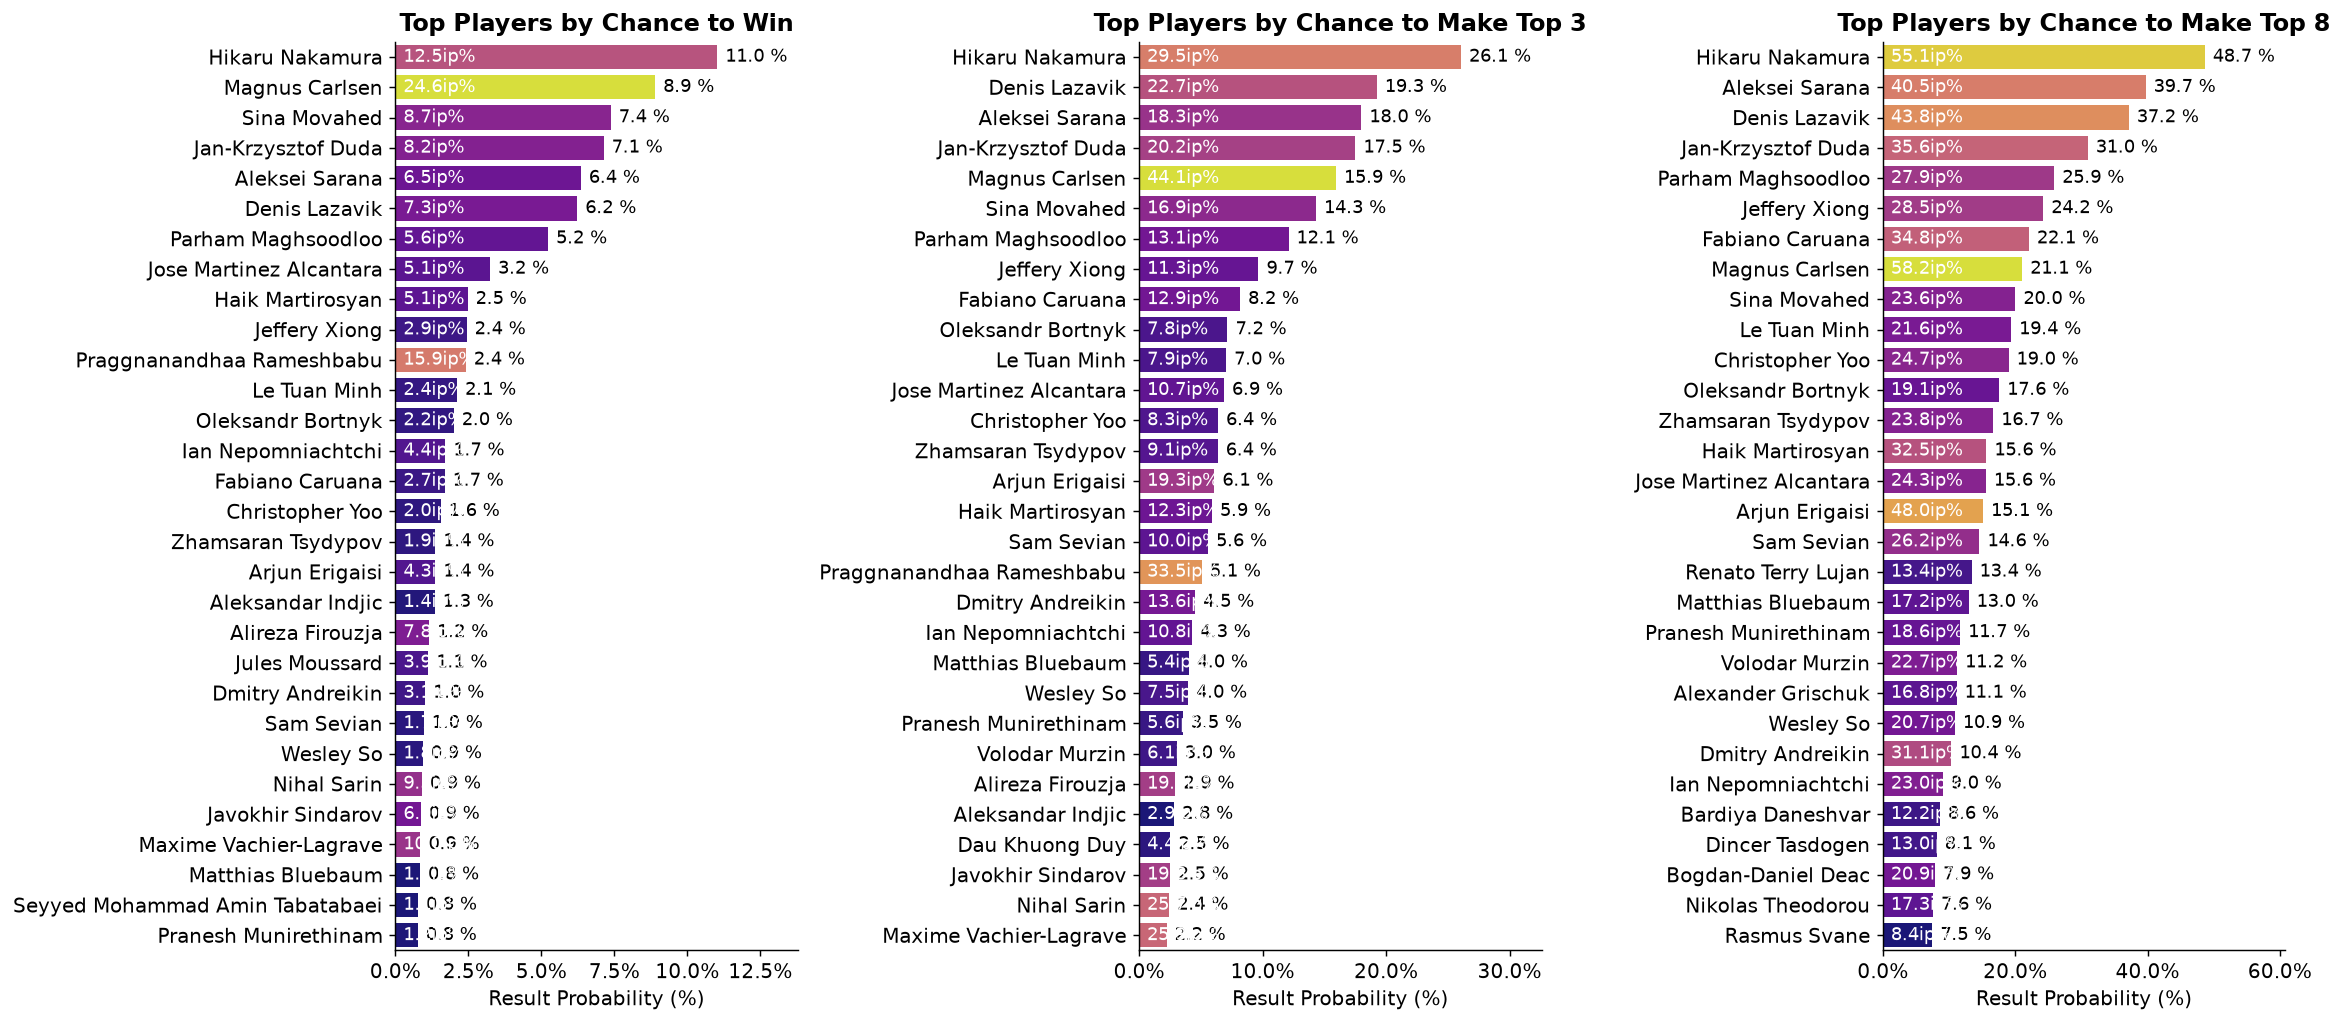

In [5]:
fig, axes = plt.subplots(1,3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    names = [USERNAME_TO_PLAYER.get(username,username) for username in df_plot['username']]

    sns.barplot(data = df_plot, x=col_chance, y=names, ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[col_chance].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Result Probability (%)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]

        ax.text(width + (max_width * 0.02), y, f'{chance_val*100:.1f} %', va = 'center', ha='left', fontsize=10, color='black')
        ax.text(max_width * 0.02, y, f'{when_val*100:.1f}ip%', va = 'center', ha='left', fontsize=10, color='white')

plt.tight_layout()
plt.show()

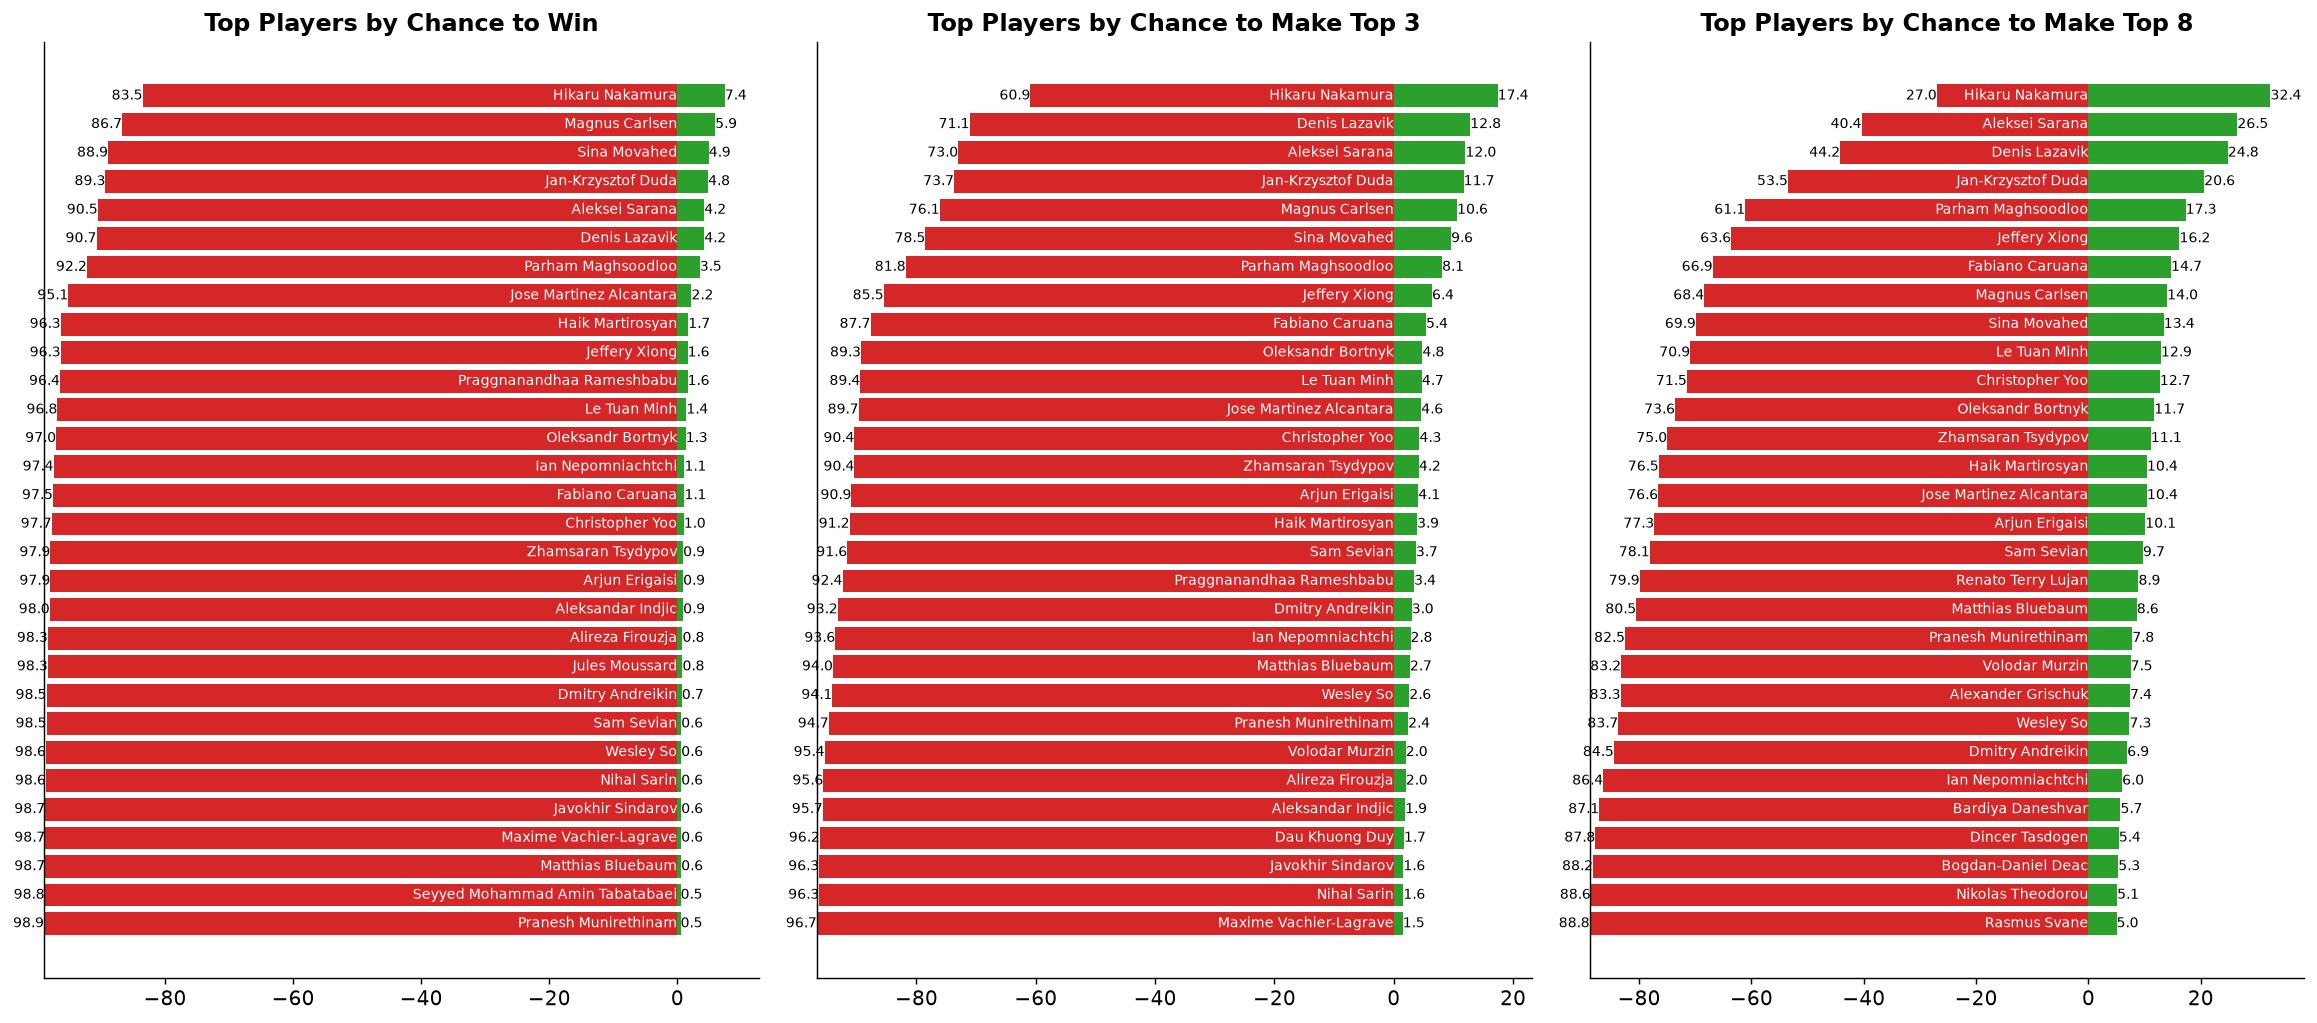

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    # Calculate Kalshi Yes and No prices
    # Using np.clip to ensure the No price doesn't drop below $0.00 if the estimate is very high (>75%)
    df_plot['Yes_Price'] = np.round(df_plot[col_chance] * (2/3) * 100, 1)
    df_plot['No_Price'] = np.round((1-df_plot[col_chance] * (3/2))*100, 1)

    # --- Plot YES Bars ---
    ax.barh(df_plot.index, df_plot['Yes_Price'], height=0.8, color='#2ca02c', label='Yes Price')

    # --- Plot NO Bars ---
    ax.barh(df_plot.index, df_plot['No_Price'], left=-df_plot['No_Price'], height=0.8, color='#d62728', label='No Price')

    # Set the Y-axis labels to the Yes Price
    ax.set_yticks([])
    ax.invert_yaxis()  # Put the highest chance player at the top
    ax.set_title(title, fontweight='bold')

    
    # Add data labels dynamically
    for i, row in df_plot.iterrows():
        yes_val = row['Yes_Price']
        no_val = row['No_Price']
        name = USERNAME_TO_PLAYER.get(row['username'],row['username'])
        
        # Text for the Yes price (placed slightly to the right of the green bar's edge)
        ax.text(yes_val, i, yes_val, va='center', ha='left', fontsize=8, color='black')
        
        # Text for the No price (placed slightly to the left of the red bar's edge)
        # The inner edge of the red bar is exactly at (1 - no_val)
        ax.text(-no_val, i, no_val, va='center', ha='right', fontsize=8, color='black')

        ax.text(0, i, name, va='center', ha='right', fontsize=8, color='white')



plt.tight_layout()
plt.show()

findfont: Failed to find font weight heavy, now using 700.


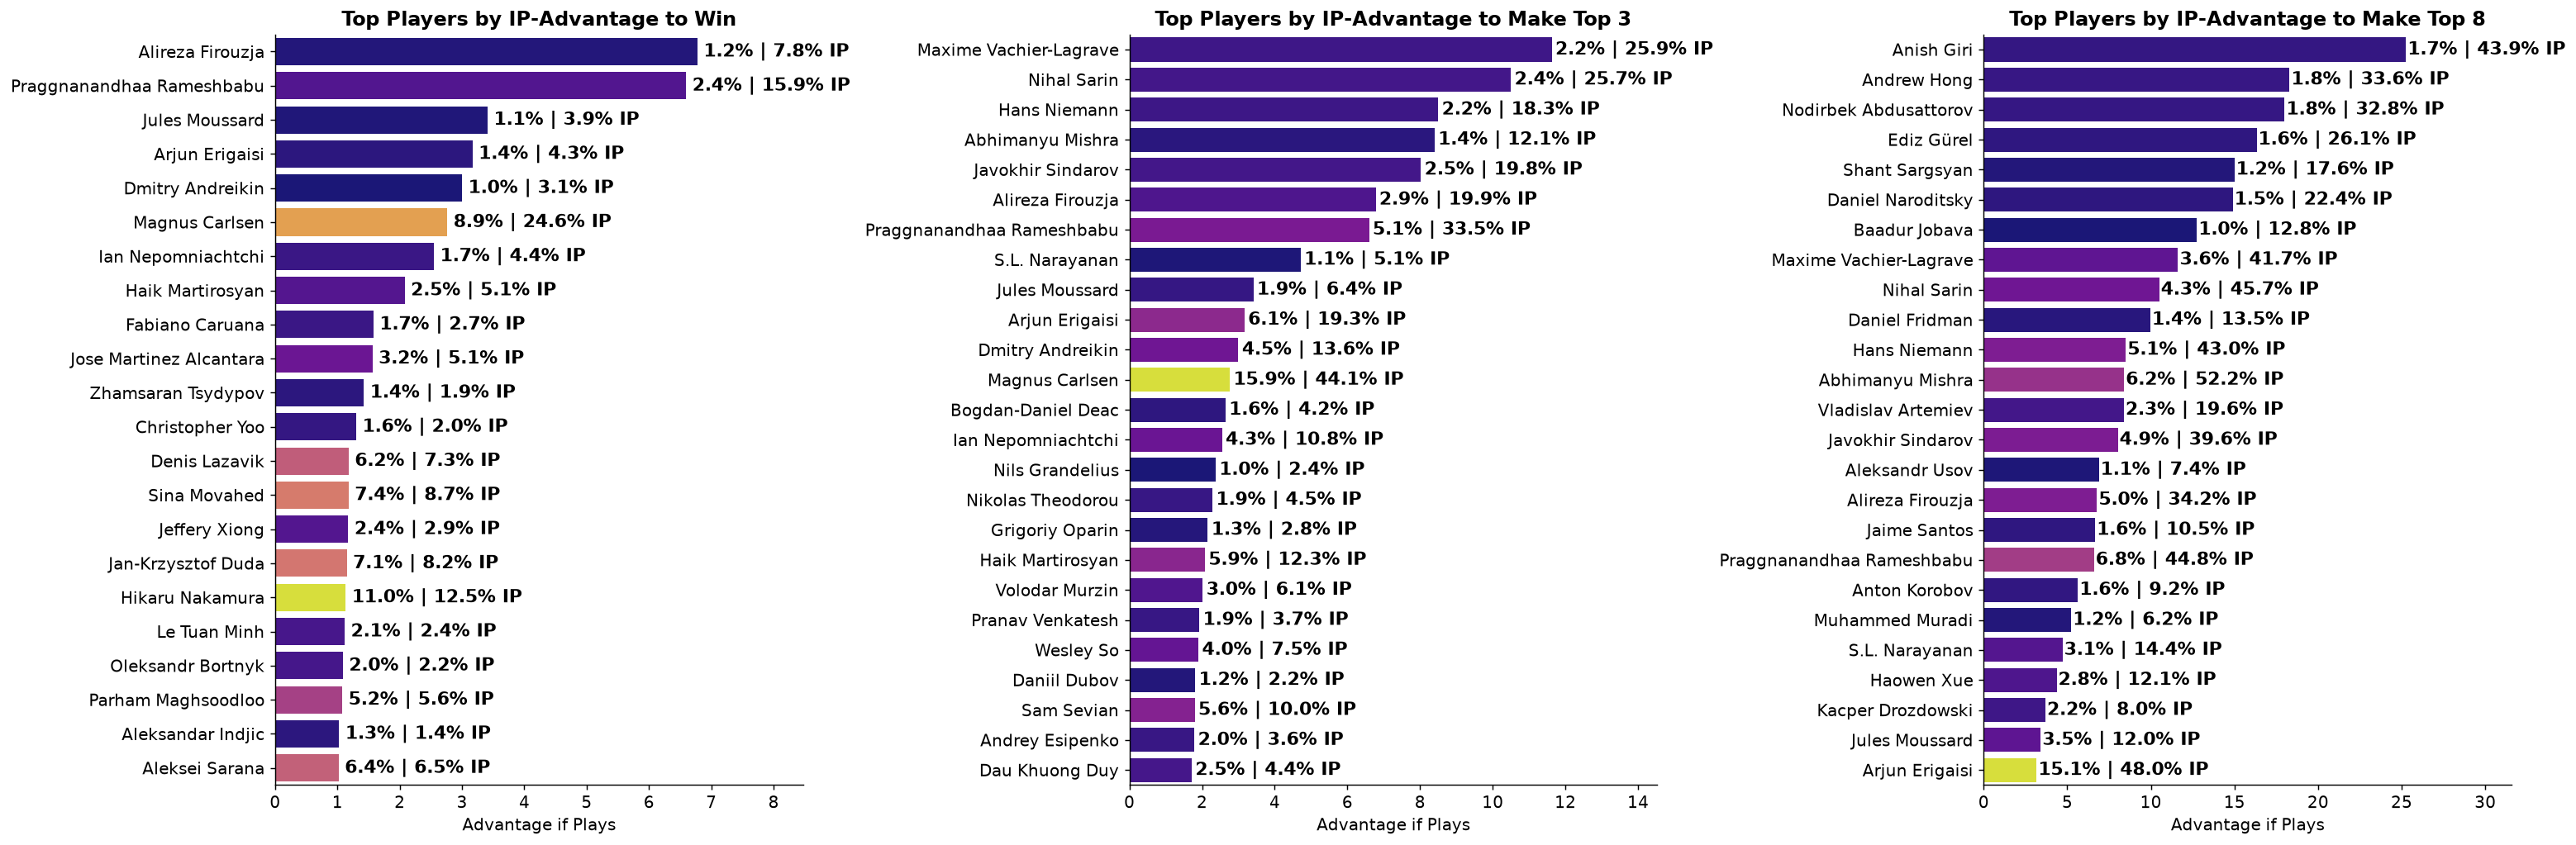

In [7]:
fig, axes = plt.subplots(1,3, figsize=(24,8))

metrics = [
    (1,'Top Players by IP-Advantage to Win'),
    (3,'Top Players by IP-Advantage to Make Top 3'),
    (8,'Top Players by IP-Advantage to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_when = f'P_top{n}'
    col_chance = f'P_top{n}_given_play'
    ip_adv = f'ip_adv_top{n}'

    df_plot = results[results[col_when]>.01].nlargest(25,ip_adv).reset_index()

    def get_name(username):
        try:
            return USERNAME_TO_PLAYER[username]
        except:
            print(username, "?")
            return username
    df_plot['name'] = df_plot['username'].apply(get_name)

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    sns.barplot(data = df_plot, x=ip_adv, y='name', ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[ip_adv].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Advantage if Plays')
    ax.set_ylabel('')

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]
        adv_val = df_plot.iloc[i][ip_adv]
        name = df_plot.iloc[i]['name']

        ax.text(adv_val+0.1, y, f'{when_val*100:.1f}% | {chance_val*100:.1f}% IP', va = 'center', ha='left', fontsize=12, color='black', fontweight='heavy')

plt.tight_layout()
plt.show()

In [8]:
def display_profits(df_tt, df_results, verbose=False):
    costs = 0
    revenue = 0
    for idx, row in df_tt.iterrows():
        costs += row['cost']

        pos = 1.0 if row['position']=='Yes' else 0.0
        username = PLAYER_TO_USERNAME[row['marketTitle']]
        n = row['n']

        if not username in df_results.index:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: -${row['cost']}")
            continue

        result = df_results.loc[username, f'P_top{n}'].item()

        if result == pos:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. +${row['volume'] - row['cost']}")
            revenue += row['volume']
        else:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
    
    return revenue - costs

def avg_profits(df, df_results, fees=0, verbose=False):
    revenues = []
    costs = []
    values = []
    values_per_share = []
    for idx, row in df.iterrows():
        username = PLAYER_TO_USERNAME[row['marketTitle']]
        n = row['n']
        costs.append(round(row['volume']*row['orderPrice'],2))

        if not username in df_results.index:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t0.0 EV per share.\t ${-row['cost']:.2f} EV\t {0:.2f}% ROI")
            revenues.append(0)
            continue

        result = df_results.loc[username, f'P_top{n}'].item()
        value = result if row['position']=='Yes' else (1-result)
        revenues.append(row['volume']*value)
        values.append(f'${value*row["volume"]:.2f}')
        values_per_share.append(value)
        if verbose:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t{value:.2f} EV per share.\t ${row['volume']*value-row['cost']:.2f} EV\t {(row['volume']*value/row['cost']-1)*100:.2f}% ROI")

    expected_return_col = [round(r-c,2) for r,c in zip(revenues, costs)]
    roi_col = [round(r/c,2) for r,c in zip(revenues, costs)]

    revenue = sum(revenues)
    cost = sum(costs)+fees
    net_profit = revenue-cost
    roi = (revenue/cost-1)*100

    print(f"Total Exposure:{cost}. Expected Revenue: {revenue}. Net profits avg: {net_profit:.2f}. ROI {roi:.2f}%")

    return expected_return_col, values, values_per_share, roi_col, costs

n_title_dict = {
    'Titled Tuesday Top 8: Jul 21': 8,
    'Titled Tuesday Top 3: Jul 21': 3,
    'Titled Tuesday Winner: Jul 21': 1
    }

kalshi_orders = pd.read_csv("../data/Kalshi-Advanced-Portfolio.csv")
df_tt = kalshi_orders[kalshi_orders['eventTitle'].str.contains('Tuesday')]
df_tt[['position','volume']] = df_tt['position'].str.split(' x ',expand=True)
df_tt['volume'] = df_tt['volume'].astype(float)
df_tt['n'] = df_tt['eventTitle'].apply(lambda x: n_title_dict[x])
df_tt['orderPrice'] = kalshi_order_price(df_tt['averagePrice'].str.extract('(\d+)').astype(float)/100.0)
df_tt['expectedReturn'], df_tt['expectedValue'], df_tt['evPerShare'], df_tt['ROI'], df_tt['cost']=avg_profits(df_tt, results)
df_tt['eventTitle'] = df_tt['eventTitle'].apply(lambda event: f'Top {n_title_dict[event]}')
df_tt[['eventTitle','marketTitle','position','ROI','averagePrice','orderPrice','evPerShare','cost','expectedValue','expectedReturn']].sort_values('ROI',ascending=False)

Total Exposure:1400.0. Expected Revenue: 1500.8992714500139. Net profits avg: 100.90. ROI 7.21%


,eventTitle,marketTitle,position,ROI,averagePrice,orderPrice,evPerShare,cost,expectedValue,expectedReturn
23,Top 3,Magnus Carlsen,Yes,1.50,10¢,0.106300,0.159496,31.89,$47.85,15.96
22,Top 3,Jan-Krzysztof Duda,Yes,1.38,12¢,0.127392,0.175215,38.85,$53.44,14.59
41,Top 1,Sina Movahed,Yes,1.38,5¢,0.053325,0.073758,5.33,$7.38,2.05
25,Top 3,Sina Movahed,Yes,1.35,10¢,0.106300,0.143335,67.61,$91.16,23.55
54,Top 8,Jan-Krzysztof Duda,Yes,1.33,22¢,0.232012,0.309716,72.16,$96.32,24.16
47,Top 8,Aleksei Sarana,Yes,1.30,29¢,0.304413,0.397160,93.15,$121.53,28.38
60,Top 8,Parham Maghsoodloo,Yes,1.29,19¢,0.200773,0.259051,61.24,$79.01,17.77
17,Top 3,Aleksei Sarana,Yes,1.21,14¢,0.148428,0.180038,64.42,$78.14,13.72
18,Top 3,Denis Lazavik,Yes,1.21,15¢,0.158925,0.192563,44.82,$54.30,9.48
49,Top 8,Denis Lazavik,Yes,1.18,30¢,0.314700,0.371703,61.37,$72.48,11.11


In [ ]:
_df_raw, p_participate, app_counts = load_and_prepare(
    cut_players=[
    'Matthias Bluebaum',
    'Levon Aronian',
    'Yagiz Kaan Erdogmus',
    'Jose Martinez Alcantara',
    'Le Quang Liem',
    'Hans Niemann',
    'Arjun Erigaisi',
    'Pranesh Munirethinam',
    'Dmitry Andreikin',
    'Nihal Sarin',
    'Alireza Firouzja',
    'Nodirbek Abdusattorov',
]
)
players, p_play, hist_pcts, hist_wts = build_player_pool(_df_raw, p_participate, app_counts)
portfolio = build_portfolio(df_tt, players, PLAYER_TO_USERNAME)
pnl = run_portfolio_mc(players, p_play, hist_pcts, hist_wts, portfolio, n_sims=20_000)
pnl_summary(pnl)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.histplot(x=pnl, kde=True, ax=ax, color='blue', bins=500)
ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')
plt.show()
plt.close(fig)

  p_participate: decay-weighted EWMA with isotonic floor (p < 0.05)
Computing conflict-conditional attendance rates...
  Msb2: 5/9 conflict TTs -> conflict_rate=0.556
  LevonAronian: 0/9 conflict TTs -> conflict_rate=0.000
  legendisback1: 0/14 conflict TTs -> conflict_rate=0.000
  Jospem: 9/12 conflict TTs -> conflict_rate=0.750
  LiemLe: 0/3 conflict TTs -> conflict_rate=0.000
  HansOnTwitch: 2/17 conflict TTs -> conflict_rate=0.118
  GHANDEEVAM2003: 6/19 conflict TTs -> conflict_rate=0.316
  artooon: only 0 conflict TT date(s) - leaving p_participate unchanged
  FairChess_on_YouTube: 1/3 conflict TTs -> conflict_rate=0.333
  nihalsarin: 2/21 conflict TTs -> conflict_rate=0.095
  Firouzja2003: 3/10 conflict TTs -> conflict_rate=0.300
  ChessWarrior7197: 1/18 conflict TTs -> conflict_rate=0.056
  Msb2: EWMA=0.740  conflict=0.556  -> p_participate=0.556
  LevonAronian: EWMA=0.121  conflict=0.000  -> p_participate=0.000
  legendisback1: EWMA=0.057  conflict=0.000  -> p_participate=0.000

In [ ]:
df_cands = df[df['ROI'] > 1.0].copy()
df_cands['n_int'] = df_cands['n'].apply(lambda x: 1 if str(x) == '21' else int(x))

df_cands_fmt = (
    df_cands
    .drop(columns=['n'])
    .rename(columns={'Player Name': 'marketTitle', 'Side': 'position', 'n_int': 'n'})
    .copy()
)
df_cands_fmt['position'] = df_cands_fmt['position'].str.title()
df_cands_fmt['volume']   = 1.0
df_cands_fmt['cost']     = df_cands_fmt['Order Price']

portfolio_cands = build_portfolio(df_cands_fmt, players, PLAYER_TO_USERNAME)

print("Running payoff matrix simulation (50k sims)...")
payoff_matrix, cost_per_share = run_payoff_matrix(
    players, p_play, hist_pcts, hist_wts,
    portfolio_cands, n_sims=50_000,
)

print("\nOptimising Kelly allocation...")
opt_shares, opt_result = portfolio_kelly(
    payoff_matrix, cost_per_share,
    bankroll=BANKROLL, kelly_fraction=KELLY_MULT,
)

df_cands['opt_shares'] = opt_shares
df_cands['opt_cost']   = opt_shares * df_cands['Order Price']
df_cands['opt_ev']     = opt_shares * df_cands['EV']
df_cands['opt_edge']   = df_cands['opt_ev'] - df_cands['opt_cost']

df_opt = df_cands[df_cands['opt_shares'] > 0].copy()
total_cost_opt = df_opt['opt_cost'].sum()
total_ev_opt   = df_opt['opt_ev'].sum()
print(f"\nPortfolio Kelly  |  Exposure ${total_cost_opt:.0f} ({total_cost_opt/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev_opt - total_cost_opt:.2f}  |  ROI {(total_ev_opt/total_cost_opt - 1)*100:.1f}%\n")

df_opt[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'opt_shares', 'opt_cost', 'opt_edge']]\
    .sort_values('opt_shares', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}',
                   'opt_cost': '${:.2f}', 'opt_edge': '${:.2f}'})

Running payoff matrix simulation (50k sims)...
   10,000 / 50,000  (5.5s)
   20,000 / 50,000  (10.8s)
   30,000 / 50,000  (16.2s)
   40,000 / 50,000  (21.6s)
   50,000 / 50,000  (26.9s)

Optimising Kelly allocation...
Converged: True  |  Exposure $1000.00 (50.0% of bankroll)  |  E[log-return]: 0.0505

Portfolio Kelly  |  Exposure $1000 (50.0%)  |  Expected edge $127.38  |  ROI 12.7%



,Market Title,Side,ROI,Order Price,EV,opt_shares,opt_cost,opt_edge
865,"Will Vladislav Artemiev finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.098000,0.887,0.975,488,$433.05,$42.58
1196,"Will Denis Lazavik finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.239000,0.304,0.377,326,$99.24,$23.68
987,"Will Oleksandr Bortnyk finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.162000,0.159,0.185,280,$44.50,$7.21
864,"Will Vladislav Artemiev finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.087000,0.897,0.975,275,$246.63,$21.39
532,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.251000,0.117,0.146,217,$25.36,$6.37
1268,"Will Aleksei Sarana finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.219000,0.335,0.409,191,$64.03,$14.01
1113,"Will Jan-Krzysztof Duda finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.101000,0.273,0.301,131,$35.82,$3.63
977,"Will Parham Maghsoodloo finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.141000,0.222,0.253,122,$27.04,$3.81
744,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.251000,0.159,0.199,61,$9.69,$2.44
269,"Will Jan-Krzysztof Duda win the Titled Tuesday weekly chess competition, originally scheduled for Jul 21, 2026 at 11:00am EDT?",YES,1.098000,0.064,0.070,47,$3.01,$0.29


In [ ]:
df_corr, pnl = compute_hedge_correlations(
    players, p_play, hist_pcts, hist_wts, portfolio,
    n_values=[1, 3, 8], n_sims=100_000,
)

show_best_hedges(df_corr, top_k=20, username_to_player=USERNAME_TO_PLAYER)

   10,000 / 100,000  (5.0s)
   20,000 / 100,000  (10.2s)
   30,000 / 100,000  (15.6s)
   40,000 / 100,000  (21.2s)
   50,000 / 100,000  (26.7s)
   60,000 / 100,000  (32.2s)
   70,000 / 100,000  (37.6s)
   80,000 / 100,000  (42.8s)
   90,000 / 100,000  (48.0s)
  100,000 / 100,000  (53.3s)

── Best YES hedges (negative correlation with portfolio) ────────
                         player  n  P(top N)  corr(YES, portfolio)
Seyyed Mohammad Amin Tabatabaei  8    0.0663               -0.1110
                   Le Tuan Minh  3    0.0690               -0.1092
                Fabiano Caruana  3    0.0776               -0.1079
                Christopher Yoo  8    0.2060               -0.1036
              Javokhir Sindarov  8    0.0512               -0.1021
                     Sam Sevian  3    0.0616               -0.1014
                Christopher Yoo  3    0.0670               -0.1013
                Fabiano Caruana  8    0.1724               -0.0981
                   Le Tuan Minh  8    0.2

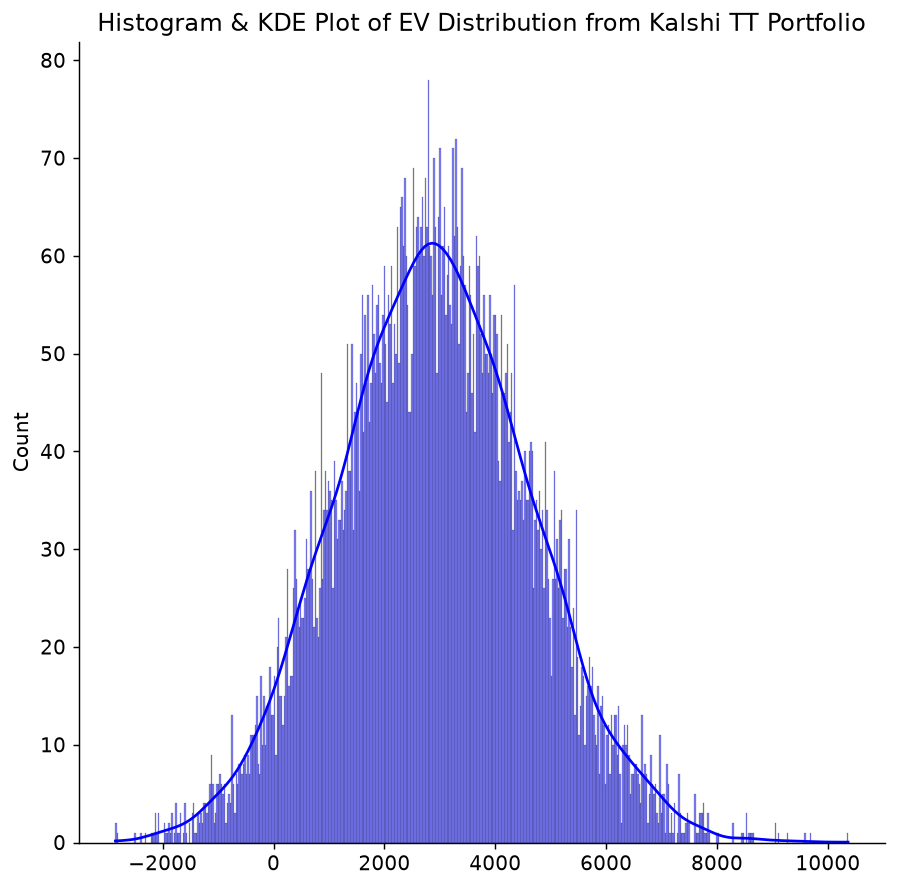

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
sns.histplot(x=[np.sum(np.random.choice(pnl,(10,))) for _ in range (10000)], kde=True, ax=ax, color='blue', bins=500)

ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')

plt.show()
plt.close(fig)

In [ ]:
def sanity_check(player_name, user=False, n=8, margin=.33):
    username = player_name
    if not user:
        username = PLAYER_TO_USERNAME[player_name]
    if username not in results.index:
        print(f'{username!r} not found in predictions (too few appearances or not in player pool).')
        return
    player_results = results.loc[username]
    fair_odds = player_results[f'P_top{n}'].item()
    if_plays = player_results[f'P_top{n}_given_play'].item()
    yes_price = fair_odds*(1-margin)
    no_price = ((1-fair_odds)*(1-margin))
    print(
        f'P({n}): {np.round(fair_odds*100,2).item()}', 
        f'YES Price: {np.round(yes_price*100,2).item()} ({margin} margin)',
        f'NO Price: {np.round(no_price*100,2).item()} ({margin} margin)',
        f'P({n}) If Plays: {np.round(if_plays*100,2).item()}',
            sep='\n')
    history = df_standings[df_standings['username']==(username)]
    display(history.tail(20))

sanity_check('MagnusCarlsen', user=True)

P(8): 16.2
YES Price: 10.85 (0.33 margin)
NO Price: 56.15 (0.33 margin)
P(8) If Plays: 59.24


,date,tournament_slug,session,rank,username,title,country,rating,score,tie_break,wins,draws,byes
270937,2025-11-04,titled-tuesday-blitz-november-04-2025-6003021,NaN,2.0,MagnusCarlsen,GM,Norway,3317,9.0,78.0,9.0,0.0,0.0
271156,2025-11-11,titled-tuesday-blitz-november-11-2025-6031699,NaN,1.0,MagnusCarlsen,GM,Norway,3349,11.0,78.0,11.0,0.0,0.0
271555,2025-11-18,titled-tuesday-blitz-november-18-2025-6051483,NaN,6.0,MagnusCarlsen,GM,Norway,3309,8.5,76.0,8.0,1.0,0.0
271951,2025-11-25,titled-tuesday-blitz-november-25-2025-6061169,NaN,2.0,MagnusCarlsen,GM,Norway,3316,9.5,74.0,9.0,1.0,0.0
272357,2025-12-02,titled-tuesday-blitz-december-02-2025-6081093,NaN,1.0,MagnusCarlsen,GM,Norway,3361,9.5,81.0,8.0,3.0,0.0
273136,2025-12-16,titled-tuesday-blitz-december-16-2025-6100509,NaN,1.0,MagnusCarlsen,GM,Norway,3378,9.5,74.0,9.0,1.0,0.0
273517,2025-12-23,titled-tuesday-blitz-december-23-2025-6110589,NaN,8.0,MagnusCarlsen,GM,Norway,3364,8.5,76.0,8.0,1.0,0.0
274196,2026-01-06,titled-tuesday-blitz-january-06-2026-6140433,NaN,1.0,MagnusCarlsen,GM,Norway,3368,9.5,76.0,9.0,1.0,0.0
274663,2026-01-13,titled-tuesday-blitz-january-13-2026-6151065,NaN,29.0,MagnusCarlsen,GM,Norway,3336,7.5,77.0,7.0,1.0,0.0
275071,2026-01-20,titled-tuesday-blitz-january-20-2026-6160609,NaN,1.0,MagnusCarlsen,GM,Norway,3308,9.5,77.0,8.0,3.0,0.0
